# Customer Churn Prediction

## 1. Imports and Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/customer_churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Understanding

In [2]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender  

## 3. Data Cleaning

In [3]:
# Check TotalCharges for blank/invalid values
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Invalid/blank TotalCharges:", total_charges_numeric.isna().sum())

print("\nRows with invalid TotalCharges:")
print(df.loc[total_charges_numeric.isna(), ['customerID', 'tenure', 'TotalCharges', 'Churn']])

# Convert TotalCharges to numeric
df['TotalCharges'] = total_charges_numeric

print("\nData types after conversion:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)

# Target distribution
print("\nChurn distribution:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

Invalid/blank TotalCharges: 11

Rows with invalid TotalCharges:
      customerID  tenure TotalCharges Churn
488   4472-LVYGI       0                 No
753   3115-CZMZD       0                 No
936   5709-LVOEQ       0                 No
1082  4367-NUYAO       0                 No
1340  1371-DWPAZ       0                 No
3331  7644-OMVMY       0                 No
3826  3213-VVOLG       0                 No
4380  2520-SGTTA       0                 No
5218  2923-ARZLG       0                 No
6670  4075-WKNIU       0                 No
6754  2775-SEFEE       0                 No

Data types after conversion:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [4]:
# Handle the 11 new customers with blank TotalCharges
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing TotalCharges after cleaning:", df['TotalCharges'].isna().sum())
print("Dataset shape:", df.shape)

print("\nTotalCharges statistics:")
print(df['TotalCharges'].describe())

Missing TotalCharges after cleaning: 0
Dataset shape: (7043, 21)

TotalCharges statistics:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


## 4. Exploratory Data Analysis

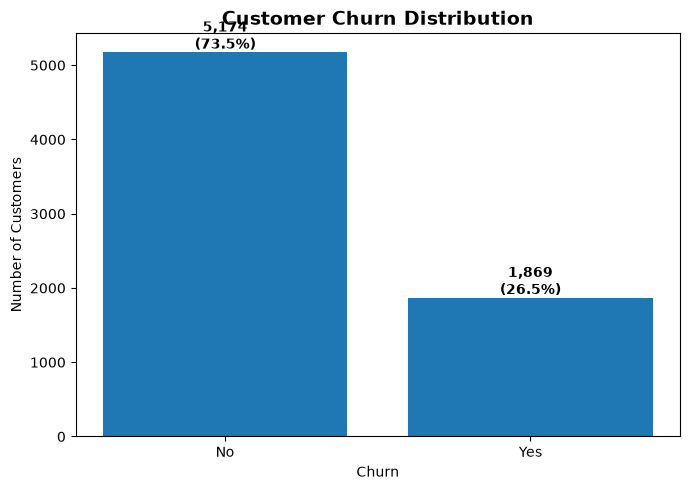

In [5]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    churn_counts.index,
    churn_counts.values
)

ax.set_title("Customer Churn Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")

for bar, count, pct in zip(
    bars,
    churn_counts.values,
    churn_percent.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [6]:
print("Churn summary:")
print(churn_counts)

print("\nPercentage:")
print(churn_percent.round(2))

Churn summary:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


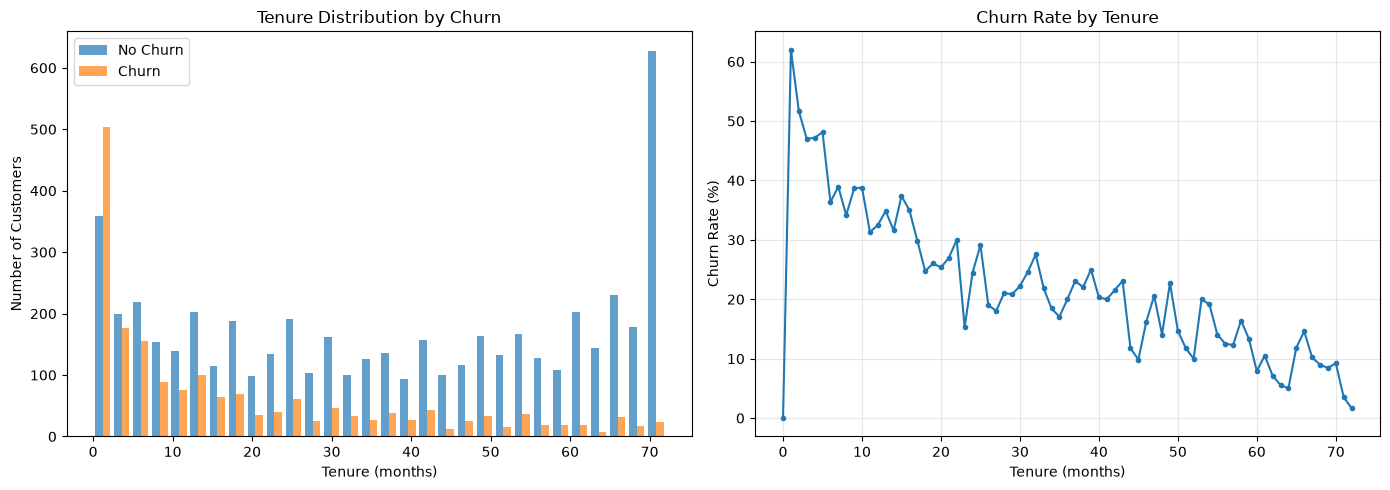

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution
axes[0].hist(
    [df.loc[df['Churn'] == 'No', 'tenure'],
     df.loc[df['Churn'] == 'Yes', 'tenure']],
    bins=30,
    label=['No Churn', 'Churn'],
    alpha=0.7
)

axes[0].set_title("Tenure Distribution by Churn")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Number of Customers")
axes[0].legend()

# Churn rate by tenure
tenure_churn = df.groupby('tenure')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

axes[1].plot(
    tenure_churn.index,
    tenure_churn.values,
    marker='o',
    markersize=3
)

axes[1].set_title("Churn Rate by Tenure")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Categorical features vs Churn

categorical_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for feature in categorical_features:
    churn_rate = (
        pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    )

    if 'Yes' in churn_rate.columns:
        churn_rate = churn_rate['Yes'].sort_values(ascending=False)

        print(f"\n{'=' * 60}")
        print(f"{feature} — Churn Rate (%)")
        print(f"{'=' * 60}")
        print(churn_rate.round(2))


gender — Churn Rate (%)
gender
Female    26.92
Male      26.16
Name: Yes, dtype: float64

SeniorCitizen — Churn Rate (%)
SeniorCitizen
1    41.68
0    23.61
Name: Yes, dtype: float64

Partner — Churn Rate (%)
Partner
No     32.96
Yes    19.66
Name: Yes, dtype: float64

Dependents — Churn Rate (%)
Dependents
No     31.28
Yes    15.45
Name: Yes, dtype: float64

PhoneService — Churn Rate (%)
PhoneService
Yes    26.71
No     24.93
Name: Yes, dtype: float64

MultipleLines — Churn Rate (%)
MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Yes, dtype: float64

InternetService — Churn Rate (%)
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Yes, dtype: float64

OnlineSecurity — Churn Rate (%)
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Yes, dtype: float64

OnlineBackup — Churn Rate (%)
OnlineBackup
No                     39.93
Yes                

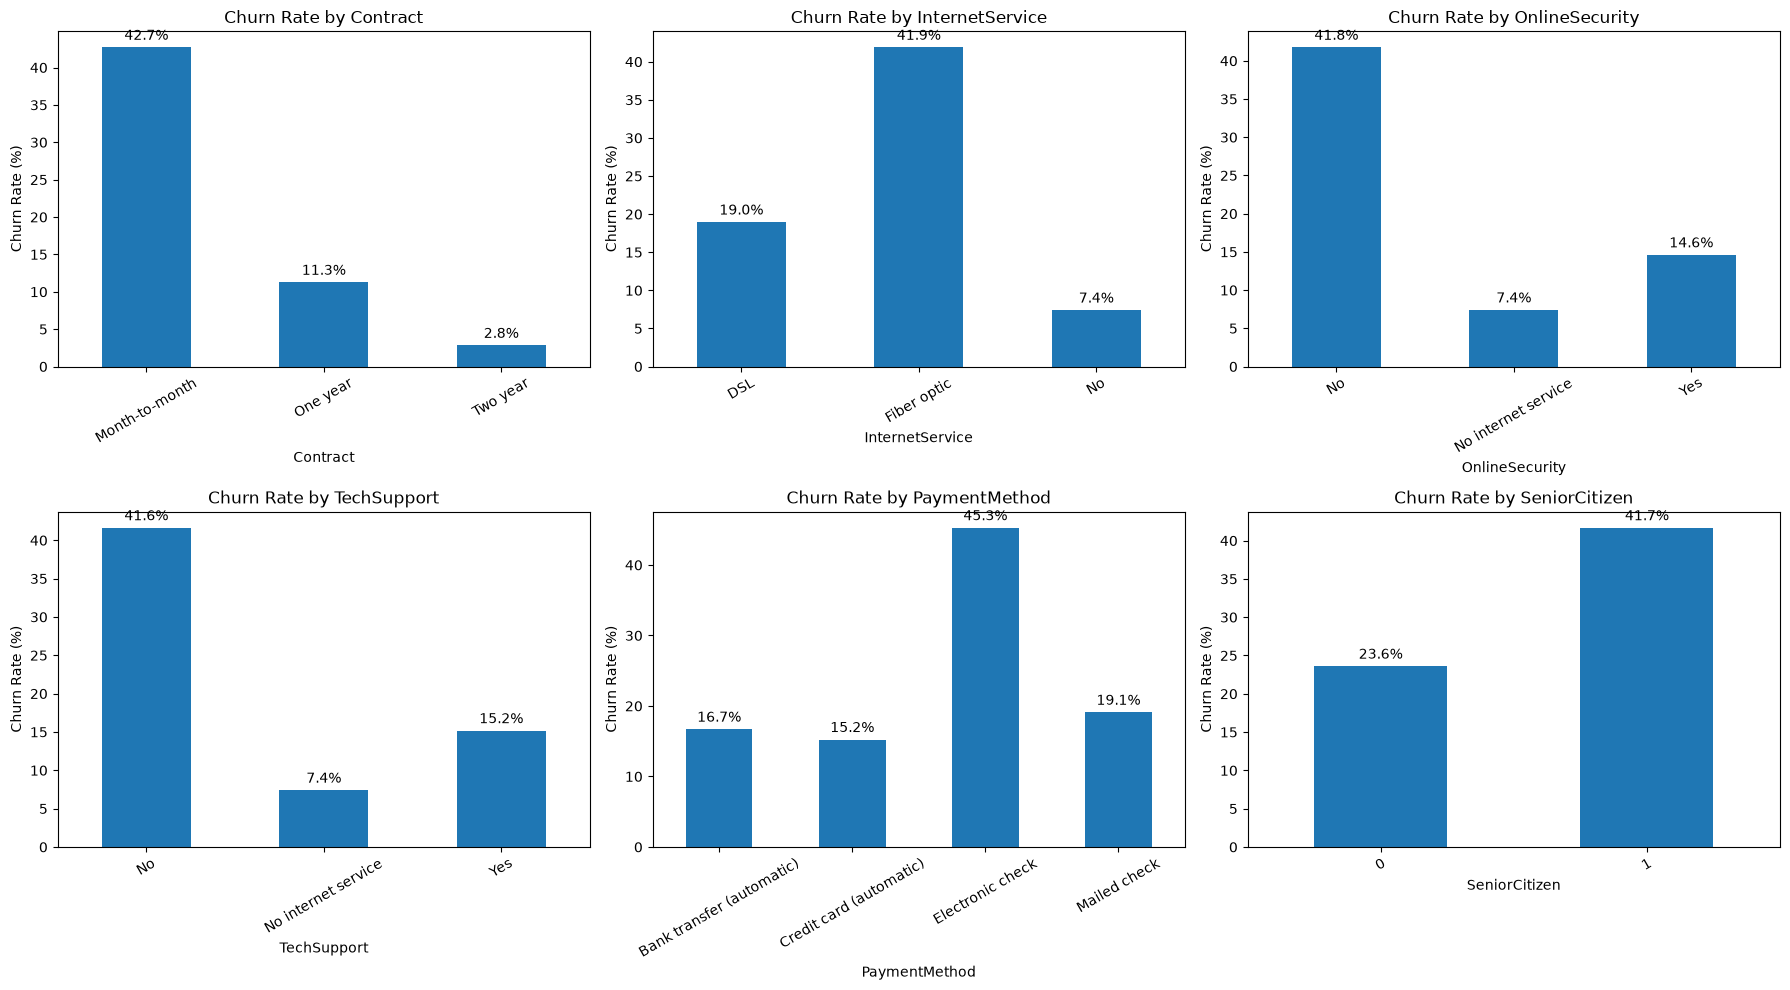

In [9]:
# Visualize the most important categorical features

important_features = [
    'Contract',
    'InternetService',
    'OnlineSecurity',
    'TechSupport',
    'PaymentMethod',
    'SeniorCitizen'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, important_features):
    churn_rate = (
        pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    )

    if 'Yes' in churn_rate.columns:
        churn_rate['Yes'].plot(kind='bar', ax=ax)

    ax.set_title(f'Churn Rate by {feature}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(feature)
    ax.tick_params(axis='x', rotation=30)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

In [10]:
# Numerical features by churn status

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Numerical feature statistics by churn:\n")

for feature in numerical_features:
    print(f"\n{'=' * 60}")
    print(feature)
    print(f"{'=' * 60}")
    
    print(
        df.groupby('Churn')[feature]
        .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        .round(2)
    )

Numerical feature statistics by churn:


tenure
       count   mean  median    std  min  max
Churn                                       
No      5174  37.57    38.0  24.11    0   72
Yes     1869  17.98    10.0  19.53    1   72

MonthlyCharges
       count   mean  median    std    min     max
Churn                                            
No      5174  61.27   64.43  31.09  18.25  118.75
Yes     1869  74.44   79.65  24.67  18.85  118.35

TotalCharges
       count     mean   median      std    min      max
Churn                                                  
No      5174  2549.91  1679.52  2329.95   0.00  8672.45
Yes     1869  1531.80   703.55  1890.82  18.85  8684.80


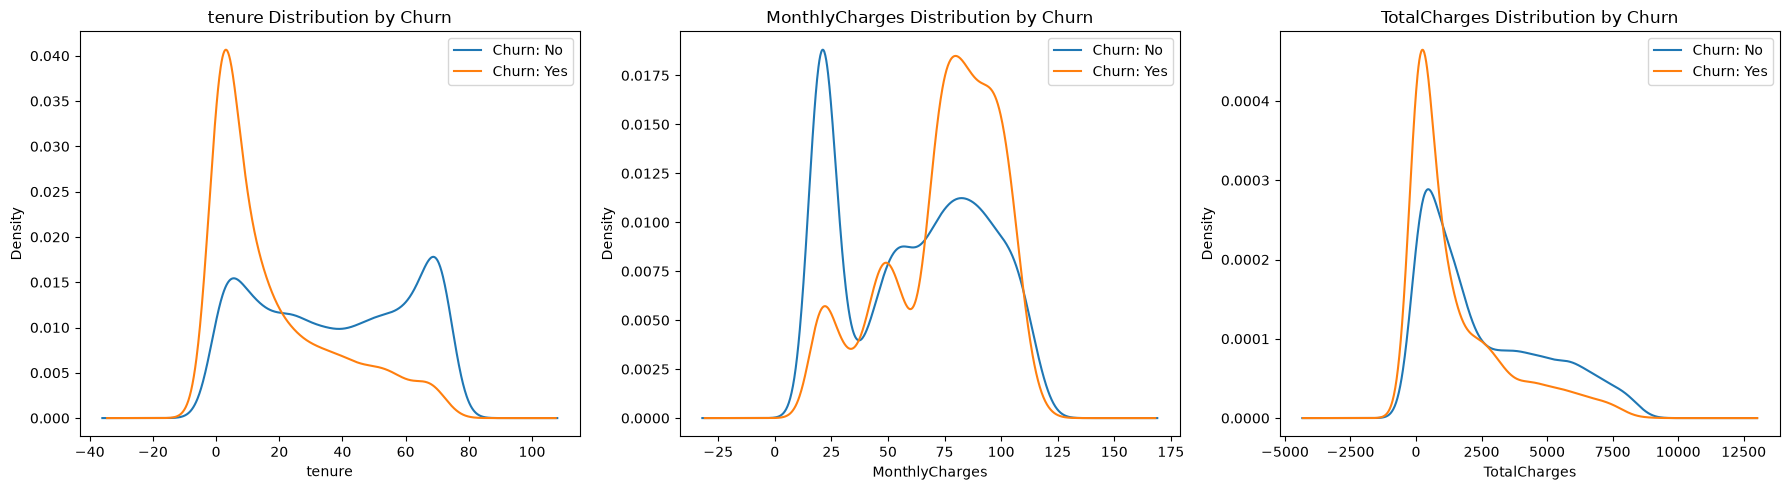

In [11]:
# Numerical feature distributions by churn

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, numerical_features):
    for churn_status in ['No', 'Yes']:
        df[df['Churn'] == churn_status][feature].plot(
            kind='kde',
            ax=ax,
            label=f'Churn: {churn_status}'
        )
    
    ax.set_title(f'{feature} Distribution by Churn')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

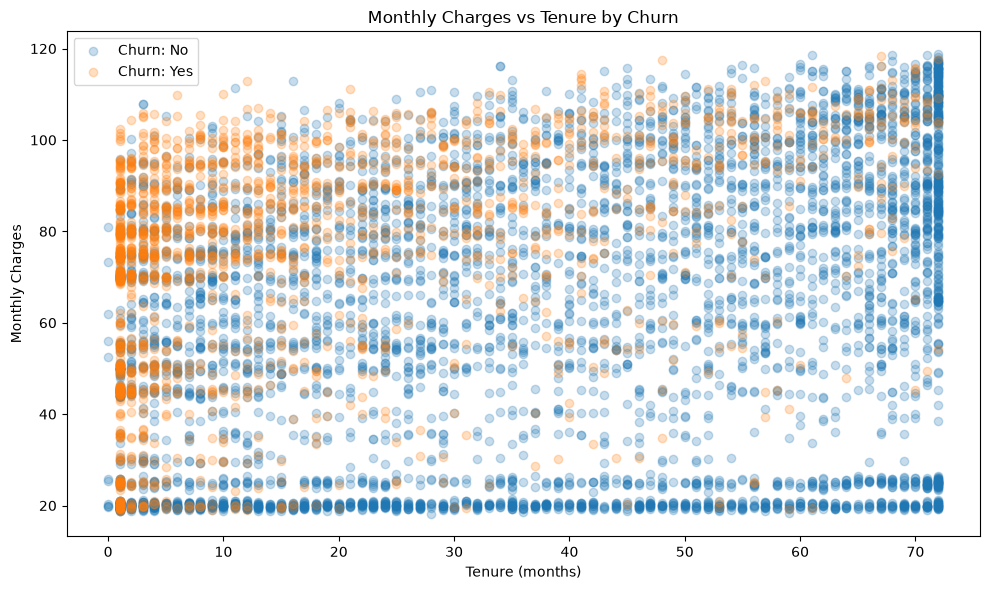

In [12]:
# Monthly charges vs tenure

plt.figure(figsize=(10, 6))

for churn_status in ['No', 'Yes']:
    subset = df[df['Churn'] == churn_status]
    plt.scatter(
        subset['tenure'],
        subset['MonthlyCharges'],
        alpha=0.25,
        label=f'Churn: {churn_status}'
    )

plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges vs Tenure by Churn')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Prepare features and target

df_model = df.copy()

# Remove customer identifier
df_model = df_model.drop('customerID', axis=1)

# Encode target
df_model['Churn'] = df_model['Churn'].map({
    'No': 0,
    'Yes': 1
})

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print("Features:", X.shape)
print("Target:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True).mul(100).round(2))

Features: (7043, 19)
Target: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target proportions:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## 5. Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn rate:", f"{y_train.mean():.2%}")
print("Test churn rate:", f"{y_test.mean():.2%}")

Training set: (5634, 19)
Test set: (1409, 19)

Training churn rate: 26.54%
Test churn rate: 26.54%


In [16]:
# Separate numerical and categorical features

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


C:\Users\Kashish\AppData\Local\Temp\ipykernel_18784\1428183027.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 6. Model Training

In [18]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [19]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Basic evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.6040
ROC-AUC  : 0.8421

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [21]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[926 109]
 [165 209]]


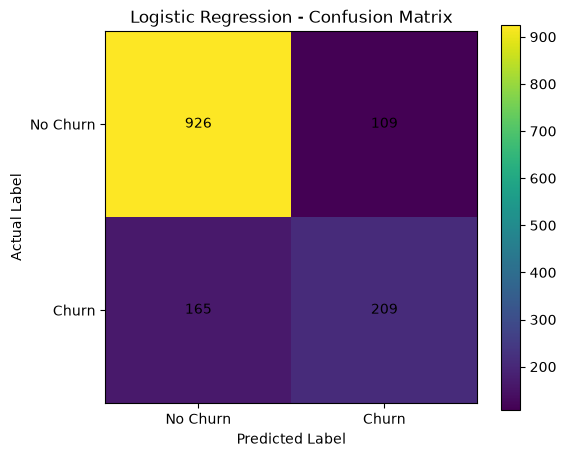

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

class-weighted Logistic Regression

In [25]:
logistic_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

logistic_balanced.fit(X_train, y_train)

y_pred_balanced = logistic_balanced.predict(X_test)
y_prob_balanced = logistic_balanced.predict_proba(X_test)[:, 1]

In [24]:
print("Balanced Logistic Regression")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_balanced):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_balanced):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_balanced):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_balanced):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=["No Churn", "Churn"]
))

Balanced Logistic Regression
Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1-Score : 0.6136
ROC-AUC  : 0.8416

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [26]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("\nConfusion Matrix:")
print(cm_balanced)


Confusion Matrix:
[[747 288]
 [ 81 293]]


In [27]:
print(f"Balanced Logistic Regression ROC-AUC: "
      f"{roc_auc_score(y_test, y_prob_balanced):.4f}")

Balanced Logistic Regression ROC-AUC: 0.8416


Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [29]:
print("Random Forest Performance")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

Random Forest Performance
Accuracy : 0.7708
Precision: 0.5606
Recall   : 0.6310
F1-Score : 0.5937
ROC-AUC  : 0.8220

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)


Confusion Matrix:
[[850 185]
 [138 236]]


In [31]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [32]:
print("XGBoost Performance")
print("=" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Churn", "Churn"]
))

XGBoost Performance
Accuracy : 0.7544
Precision: 0.5255
Recall   : 0.7727
F1-Score : 0.6255
ROC-AUC  : 0.8445

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



In [33]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix:")
print(cm_xgb)


Confusion Matrix:
[[774 261]
 [ 85 289]]


In [34]:
xgb_model.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [35]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best threshold based on F1-score:")
print(best_threshold)

Best threshold based on F1-score:
threshold    0.540000
precision    0.552941
recall       0.754011
f1           0.638009
Name: 44, dtype: float64


## 8. Model Evaluation

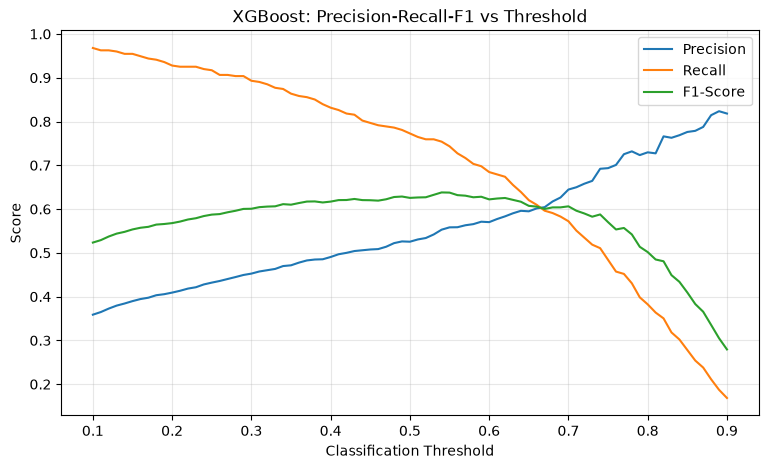

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost: Precision-Recall-F1 vs Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 9. Threshold Optimization

In [37]:
# Final predictions using optimized threshold
best_threshold = 0.54

y_pred_xgb_tuned = (y_prob_xgb >= best_threshold).astype(int)

# Confusion matrix
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

print("XGBoost - Tuned Threshold Performance")
print("=" * 45)
print(f"Threshold : {best_threshold}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_xgb_tuned):.4f}")

print("\nConfusion Matrix:")
print(cm_xgb_tuned)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb_tuned,
    target_names=["No Churn", "Churn"]
))

XGBoost - Tuned Threshold Performance
Threshold : 0.54
Accuracy  : 0.7729
Precision : 0.5529
Recall    : 0.7540
F1-Score  : 0.6380

Confusion Matrix:
[[807 228]
 [ 92 282]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.78      0.83      1035
       Churn       0.55      0.75      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [39]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "XGBoost (Tuned)"
    ],
    "Accuracy": [
        0.8055,
        0.7708,
        0.7544,
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        0.6572,
        0.5606,
        0.5255,
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        0.5588,
        0.6310,
        0.7727,
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1": [
        0.6040,
        0.5937,
        0.6255,
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    "ROC-AUC": [
        0.8421,
        0.8220,
        0.8445,
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805500,0.657200,0.558800,0.604000,0.842100
1,Random Forest,0.770800,0.560600,0.631000,0.593700,0.822000
2,XGBoost,0.754400,0.525500,0.772700,0.625500,0.844500
3,XGBoost (Tuned),0.772889,0.552941,0.754011,0.638009,0.844452


## 10. Feature Importance

In [41]:
# Extract the actual XGBoost model from the pipeline
xgb_estimator = xgb_model.steps[-1][1]

# Get feature names after preprocessing
feature_names = xgb_model[:-1].get_feature_names_out()

# Get XGBoost feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_estimator.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
36,cat__Contract_Month-to-month,0.340475
16,cat__InternetService_Fiber optic,0.080844
19,cat__OnlineSecurity_No internet service,0.062278
18,cat__OnlineSecurity_No,0.059429
27,cat__TechSupport_No,0.044851
38,cat__Contract_Two year,0.030737
15,cat__InternetService_DSL,0.028602
17,cat__InternetService_No,0.025830
43,cat__PaymentMethod_Electronic check,0.019724
35,cat__StreamingMovies_Yes,0.019610


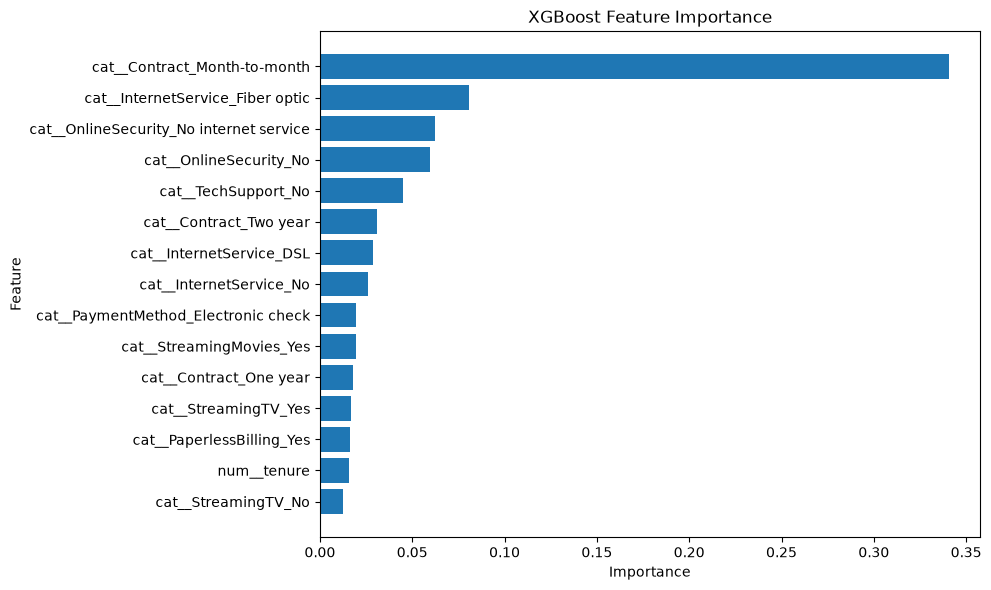

In [42]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [43]:
import joblib

joblib.dump(xgb_model, "../xgb_churn_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [44]:
model_config = {
    "model": "XGBoost",
    "threshold": 0.54
}

joblib.dump(model_config, "../model_config.pkl")

print("Model configuration saved successfully!")

Model configuration saved successfully!
